In [99]:
# Assistant
import numpy as np
import pandas as pd

from scipy.stats import skew

from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.ensemble import StackingRegressor
from sklearn.metrics import mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor


# Read csv file for train and testing shape
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

y = train["revenue"]
train.drop(["revenue"], axis=1, inplace=True)

In [100]:
train.info()
test.info()
train.head
test.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 42 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Id          137 non-null    int64  
 1   Open Date   137 non-null    object 
 2   City        137 non-null    object 
 3   City Group  137 non-null    object 
 4   Type        137 non-null    object 
 5   P1          137 non-null    int64  
 6   P2          137 non-null    float64
 7   P3          137 non-null    float64
 8   P4          137 non-null    float64
 9   P5          137 non-null    int64  
 10  P6          137 non-null    int64  
 11  P7          137 non-null    int64  
 12  P8          137 non-null    int64  
 13  P9          137 non-null    int64  
 14  P10         137 non-null    int64  
 15  P11         137 non-null    int64  
 16  P12         137 non-null    int64  
 17  P13         137 non-null    float64
 18  P14         137 non-null    int64  
 19  P15         137 non-null    i

,Id,Open Date,City,City Group,Type,P1,P2,P3,P4,P5,...,P28,P29,P30,P31,P32,P33,P34,P35,P36,P37
0,0,01/22/2011,Niğde,Other,FC,1,4.0,4.0,4.0,1,...,2.0,3.0,0,0,0,0,0,0,0,0
1,1,03/18/2011,Konya,Other,IL,3,4.0,4.0,4.0,2,...,1.0,3.0,0,0,0,0,0,0,0,0
2,2,10/30/2013,Ankara,Big Cities,FC,3,4.0,4.0,4.0,2,...,2.0,3.0,0,0,0,0,0,0,0,0
3,3,05/06/2013,Kocaeli,Other,IL,2,4.0,4.0,4.0,2,...,2.0,3.0,0,4,0,0,0,0,0,0
4,4,07/31/2013,Afyonkarahisar,Other,FC,2,4.0,4.0,4.0,1,...,5.0,3.0,0,0,0,0,0,0,0,0


In [101]:
# log y to transform it
y_log = np.log1p(y)

In [102]:
#combine the 2 datasets for feature engineering
all_data = pd.concat([train, test], axis=0)
all_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 100137 entries, 0 to 99999
Data columns (total 42 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Id          100137 non-null  int64  
 1   Open Date   100137 non-null  object 
 2   City        100137 non-null  object 
 3   City Group  100137 non-null  object 
 4   Type        100137 non-null  object 
 5   P1          100137 non-null  int64  
 6   P2          100137 non-null  float64
 7   P3          100137 non-null  float64
 8   P4          100137 non-null  float64
 9   P5          100137 non-null  int64  
 10  P6          100137 non-null  int64  
 11  P7          100137 non-null  int64  
 12  P8          100137 non-null  int64  
 13  P9          100137 non-null  int64  
 14  P10         100137 non-null  int64  
 15  P11         100137 non-null  int64  
 16  P12         100137 non-null  int64  
 17  P13         100137 non-null  float64
 18  P14         100137 non-null  int64  
 19  P15

In [103]:
# Drop ID column (not needed)
if 'Id' in all_data.columns:
    all_data = all_data.drop(columns=['Id'])


<AxesSubplot:>

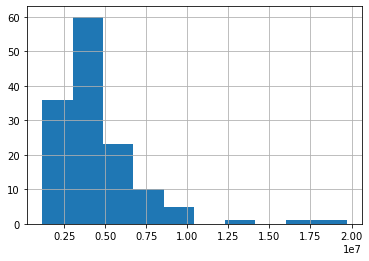

In [104]:
# Distribution of Revenue
y.hist()

In [105]:
# Sort the features into categorical or numerical
num_features = all_data.select_dtypes(include=["int64", "float64"]).columns
cat_features = all_data.select_dtypes(include=["object"]).columns

In [106]:
#Check for the columns with null values in the combined dataset
all_data.columns[all_data.isnull().any()].tolist()

[]

In [107]:
# Feature Engineering
# For Open date, extract the year, the months, the duration that it was opened, open day of the week
all_data['Open Date'] = pd.to_datetime(all_data['Open Date'])
all_data['DaysOpen'] = (pd.to_datetime('today') - all_data['Open Date']).dt.days

#Extracting how many years and month the place has been open
all_data['YearsOpen'] = all_data['DaysOpen'] / 365.0
all_data['MonthsOpen'] = all_data['DaysOpen'] * 30.0

#Extracting date, month, year from Open Date
all_data['OpenMonth'] = all_data['Open Date'].dt.month
all_data['OpenYear'] = all_data['Open Date'].dt.year
all_data['OpenDay'] = all_data['Open Date'].dt.day
all_data['OpenQuarter'] = all_data['Open Date'].dt.quarter
all_data['OpenDayOfWeek'] = all_data['Open Date'].dt.dayofweek

In [108]:
# Drop Open Date Column
all_data.drop('Open Date', axis=1, inplace=True)

In [109]:
cat_cols = ['City', 'City Group', 'Type']
all_data = pd.get_dummies(all_data, columns=cat_cols, drop_first=True)


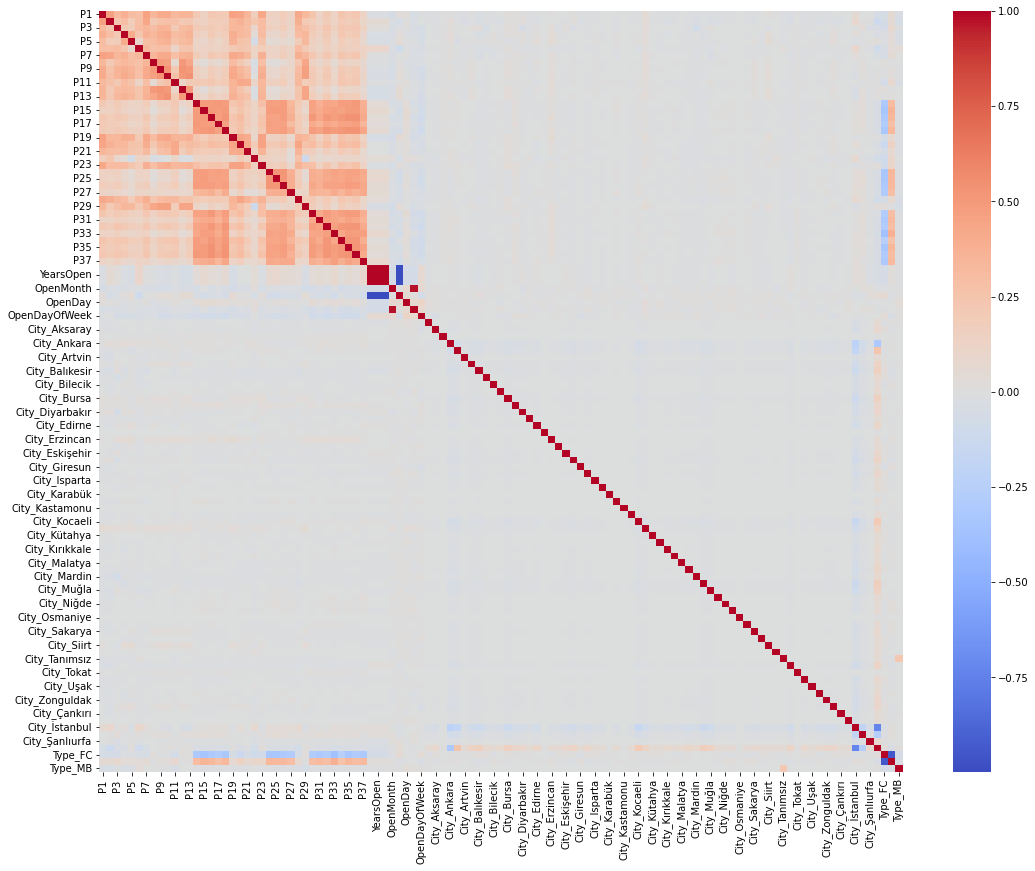

In [110]:
plt.figure(figsize=(18, 14))
sns.heatmap(all_data.corr(), cmap='coolwarm')
plt.show()


In [111]:
#Find correlation with target outcome
corr_target = pd.concat([all_data.iloc[:len(train)], y], axis=1).corr()['revenue']
corr_target.sort_values(ascending=False)


revenue           1.000000
City_İstanbul     0.332072
YearsOpen         0.325821
DaysOpen          0.325821
MonthsOpen        0.325821
                    ...   
City_Zonguldak         NaN
City_Çanakkale         NaN
City_Çankırı           NaN
City_Çorum             NaN
Type_MB                NaN
Name: revenue, Length: 112, dtype: float64

/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/seaborn/matrix.py:654: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


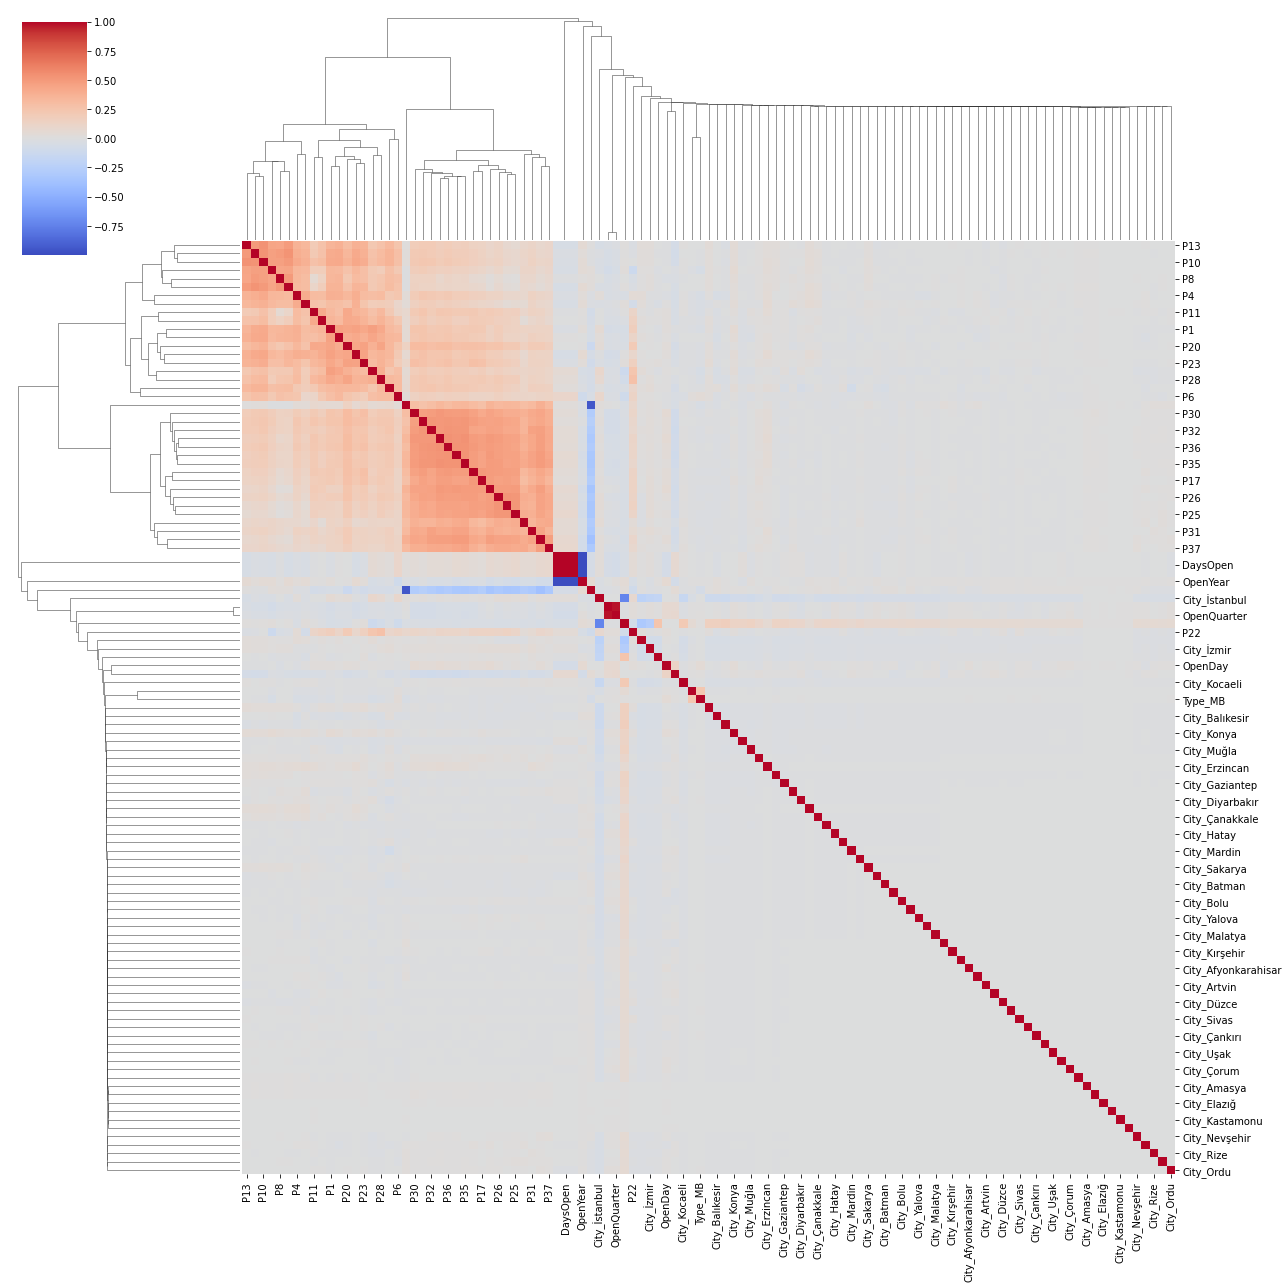

In [112]:
#Cluster map to see correlated features for combination
sns.clustermap(all_data.corr(), cmap='coolwarm', figsize=(18, 18))

In [113]:
#Indentify P columns
p_cols = [c for c in all_data.columns if c.startswith("P")]

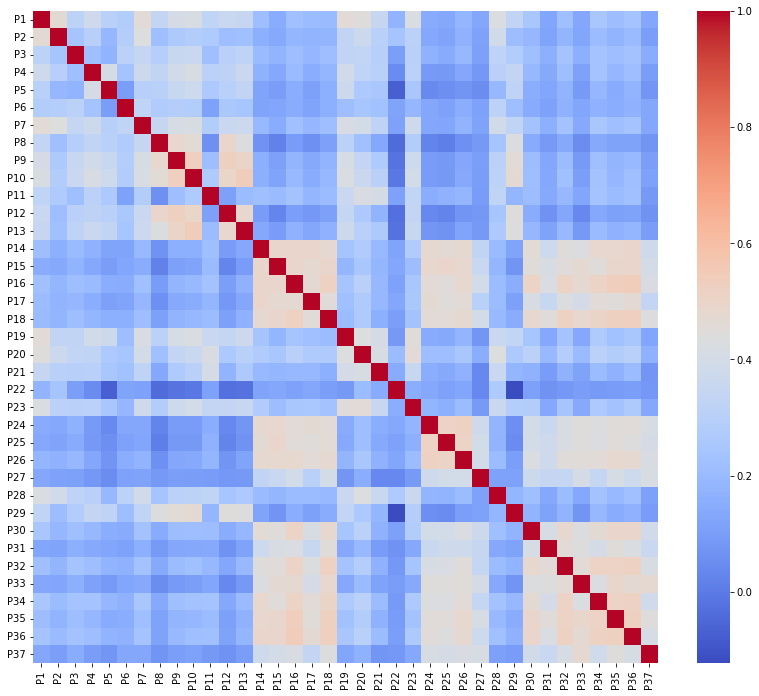

In [114]:
# Heatmap to help with correlating among P features
plt.figure(figsize=(14, 12))
sns.heatmap(all_data[p_cols].corr(), cmap='coolwarm')
plt.show()


In [115]:
corr_matrix = all_data[p_cols].corr().abs()

# threshold for grouping up

threshold = 0.75

groups = []
used = set()

for col in corr_matrix.columns:
    if col not in used:
        group = corr_matrix.index[corr_matrix[col] > threshold].tolist()
        used.update(group)
        groups.append(group)

groups

[['P1'],
 ['P2'],
 ['P3'],
 ['P4'],
 ['P5'],
 ['P6'],
 ['P7'],
 ['P8'],
 ['P9'],
 ['P10'],
 ['P11'],
 ['P12'],
 ['P13'],
 ['P14'],
 ['P15'],
 ['P16'],
 ['P17'],
 ['P18'],
 ['P19'],
 ['P20'],
 ['P21'],
 ['P22'],
 ['P23'],
 ['P24'],
 ['P25'],
 ['P26'],
 ['P27'],
 ['P28'],
 ['P29'],
 ['P30'],
 ['P31'],
 ['P32'],
 ['P33'],
 ['P34'],
 ['P35'],
 ['P36'],
 ['P37']]

In [116]:
# Create combined features 
for group in groups:
    name = "_".join(group) + "_sum"
    all_data[name] = all_data[group].sum(axis = 1)

    name = "_".join(group) + "_mean"
    all_data[name] = all_data[group].mean(axis = 1)
    

In [117]:
# Global Aggregates of P‑Features

all_data['P_sum_all'] = all_data[p_cols].sum(axis=1)
all_data['P_mean_all'] = all_data[p_cols].mean(axis=1)
all_data['P_std_all'] = all_data[p_cols].std(axis=1)
all_data['P_max_all'] = all_data[p_cols].max(axis=1)
all_data['P_min_all'] = all_data[p_cols].min(axis=1)

In [118]:
# Skew Correction

numeric_cols = all_data.select_dtypes(include=[np.number]).columns
skewness = all_data[numeric_cols].skew().sort_values(ascending=False)

skewed = skewness[skewness > 0.75].index
all_data[skewed] = np.log1p(all_data[skewed])

In [119]:
# Split into training and testing set again

X_train = all_data.iloc[:len(train)]
X_test = all_data.iloc[len(train):]

In [120]:
# Scale Features for Linear models(Lasso, Ridge, ElasticNet) 
# Testing out Tree Models(XGBoost, LightGBM, RandomForest)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [121]:
# Set up K fold cross validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

In [130]:
# Linear models (Lasso, Ridge and Elastic)
models = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.0005),
    "ElasticNet": ElasticNet(alpha=0.0005, l1_ratio=0.5),

    "RandomForest": RandomForestRegressor(
        n_estimators=500,
        random_state=42
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        random_state=42,
        verbose =- 1
    ),

    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42
    )
}



results = {}

for name, model in models.items():
    # Linear models use scaled X
    if name in ["Ridge", "Lasso", "ElasticNet"]:
        X_used = X_train_scaled
    else:
        X_used = X_train

    scores = -cross_val_score(
        model,
        X_used,
        y_log,
        cv=kfold,
        scoring='neg_mean_absolute_error'
    )

    results[name] = scores.mean()

print(results)

# Display MAE resutls to compare
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['MAE'])
print(results_df.sort_values('MAE'))

/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:647: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.024e-03, tolerance: 2.835e-03
  model = cd_fast.enet_coordinate_descent(
/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:647: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.425e-01, tolerance: 2.613e-03
  model = cd_fast.enet_coordinate_descent(
/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:647: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or

{'Ridge': 0.4835024872414464, 'Lasso': 0.5455593350114181, 'ElasticNet': 0.6027533681863877, 'RandomForest': 0.33748725729961004, 'LightGBM': 0.37159325760888146, 'XGBoost': 0.3529489055859306}
                   MAE
RandomForest  0.337487
XGBoost       0.352949
LightGBM      0.371593
Ridge         0.483502
Lasso         0.545559
ElasticNet    0.602753


In [132]:
# Fit final model and predict
best_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

# Fit model
best_model.fit(X_train, y_log)


RandomForestRegressor(n_estimators=500, n_jobs=-1, random_state=42)

In [133]:
# Predict on testing set
preds_log = best_model.predict(X_test)

In [134]:
# Reverse log transform to get real revenue
preds = np.expm1(preds_log)

In [137]:
# Create Submission
submission = pd.DataFrame({
    "Id": np.arange(len(preds)), # put Id back
    "Prediction": preds  # your final revenue predictions
})

submission.to_csv("submission.csv", index=False)
